In [17]:
import numpy as np
from PIL import Image 
import torch
import torch.nn as nn
from scipy.integrate import odeint 
import matplotlib.pyplot as plt

In [18]:
L= 0.025
g = 9.81
w = np.sqrt(g/L)
k = w**2
end_time = 1

torch.Size([500, 1]) torch.Size([500, 1])
torch.Size([10, 1]) torch.Size([10, 1])


C:\Users\saile\AppData\Local\Temp\ipykernel_34480\3614983748.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return initial_state[0]*np.cos(w*x)


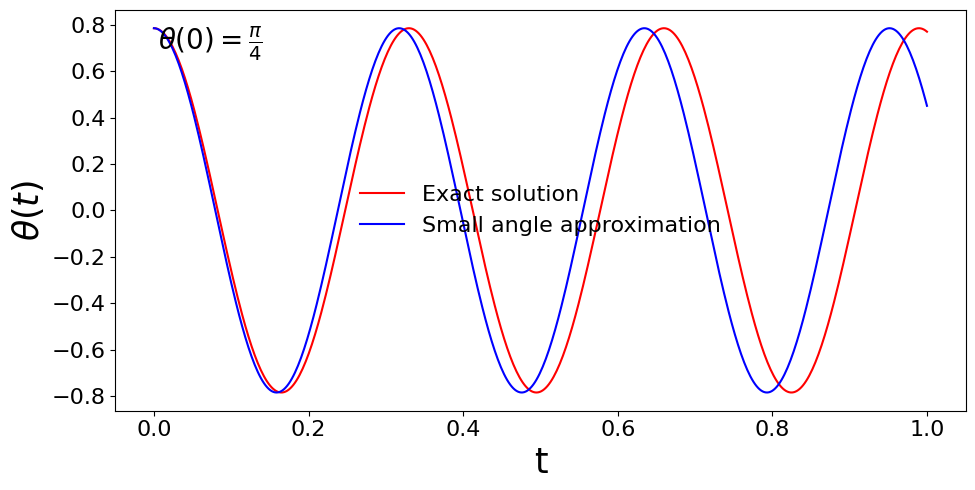

In [19]:
def simple_pendulum_eqn(state, t, L, g):
    theta, theta_dot = state
    theta_ddot = -k*np.sin(theta)
    return [theta_dot, theta_ddot]
initial_state = [np.pi/4,0]

def pendulum_solution(w,x):
    return initial_state[0]*np.cos(w*x)
  # Create a one-dimensional time array
t = np.linspace(0, end_time, 500)
x = torch.tensor(t, dtype=torch.float32).view(-1, 1)
    
    # Numerical solution of the simple pendulum ODEs
states = odeint(simple_pendulum_eqn, initial_state, t, args=(L, g))
y = torch.tensor(states[:, 0], dtype=torch.float32).view(-1, 1)
print(x.shape, y.shape)
    
x_data = x[0:200:20]
y_data = y[0:200:20]
print(x_data.shape, y_data.shape)
    
    # View the analytical solution
View_Analytical_Solution = True
if View_Analytical_Solution:
    fig = plt.figure(figsize=(10, 5))
    plt.plot(x, y, label='Exact solution', color='red')
    plt.plot(x, pendulum_solution(w, x), label='Small angle approximation', color='blue')
    plt.xlabel('t', fontsize=25)
    plt.ylabel(r'$\theta(t)$', fontsize=25)
    plt.tick_params(labelsize=16)
    plt.legend(frameon=False, fontsize=16)
    
        # annotate the initial condition in text
    plt.text(0.05, 0.9, r'$\theta(0) = \frac{\pi}{4}$', fontsize=20, transform=plt.gca().transAxes)
    
    plt.tight_layout()
    plt.savefig('solution.svg', bbox_inches='tight', pad_inches=0.1)
    plt.show()




In [20]:
class FCN(nn.Module):
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn. Sequential(*[
                          nn.Linear(N_INPUT, N_HIDDEN),
                         activation()])
        self.fch = nn.Sequential(*[
                            nn.Sequential(*[
                                nn.Linear(N_HIDDEN, N_HIDDEN), 
                                activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
            x =self.fcs(x)
            x = self.fch(x)
            x = self.fce(x)
            return x
        
def save_gif_PIL(outfile, files, fps=5, loop=0):
    imgs = [Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='GIF', append_images=imgs[1:], save_all= True, duration=int(1000/fps), loop=loop)

def plot_result(x,y, x_data, y_data, yh, xp=None):
    plt.figure(figsize=(8,4))
    plt.plot(x,y, color="tab:green", linewidth=2, alpha=0.8, label="Exact solution")
    plt.plot(x,pendulum_solution(w, x), color="tab:grey", ls='--', linewidth=2, alpha=0.5, label="Small angle approximation")
    plt.plot(x,yh, color="tab:blue", linewidth=4, alpha=0.8, label="Neural network prediction")
    plt.scatter(x_data, y_data, s=60, color="tab:orange", alpha=0.4, label='Training data')
    l = plt.legend(loc=(1.01,0.34), frameon=False, fontsize="large")
    plt.setp(l.get_texts(), color="k")
    plt.xlim(-0.05, end_time+0.05)
    plt.ylim(-1.1, 1.1)
    plt.text(1.065,0.7,"Training step: %i"%(i+1),fontsize="xx-large",color="k")
    plt.axis("off") 
         

C:\Users\saile\AppData\Local\Temp\ipykernel_34480\3614983748.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return initial_state[0]*np.cos(w*x)


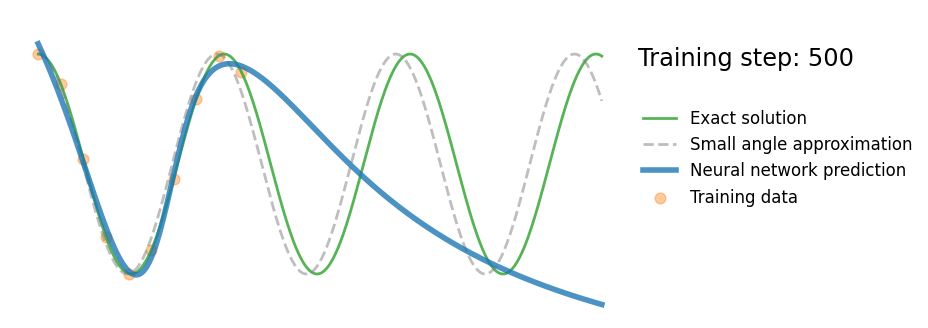

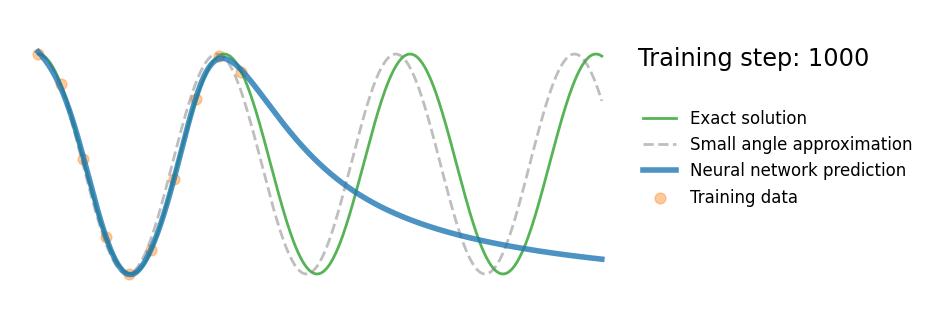

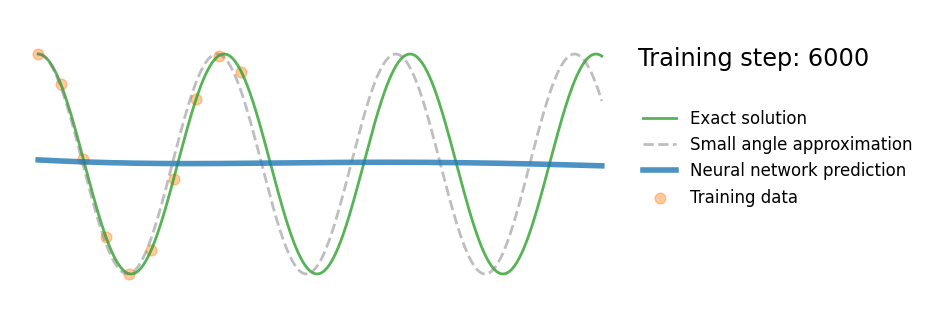

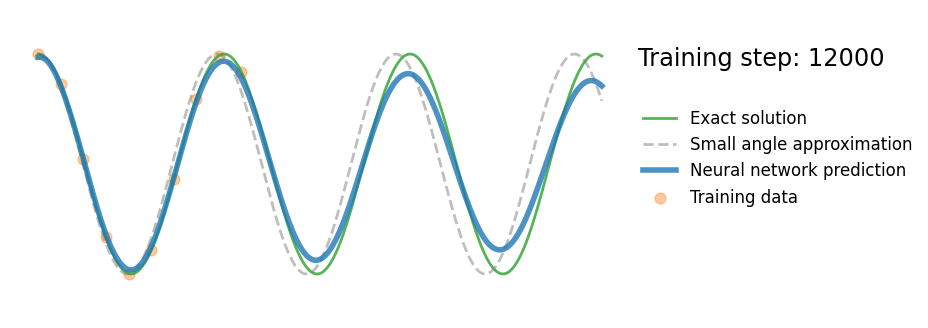

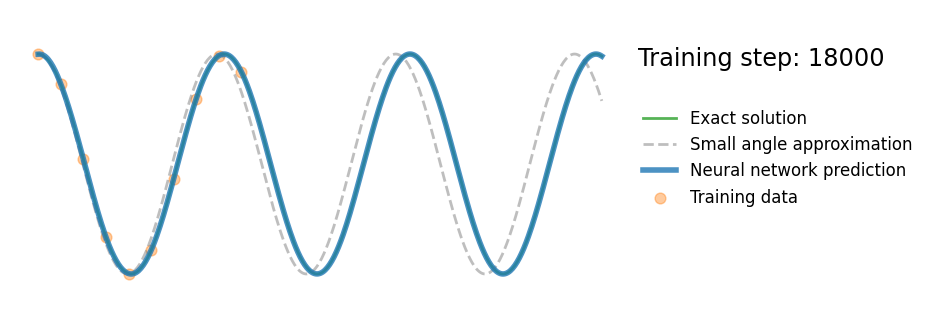

In [23]:
# ===================================================================================================== #
# train standard neural network to fit training data
import os
os.makedirs("plots", exist_ok=True)

class FCN(nn.Module):  # ✅ 'class' keyword was missing
    "Defines a connected network"
    
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
        
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

# ===================================================================================================== #
def save_gif_PIL(outfile, files, fps=5, loop=0):
    "Helper function for saving GIFs"
    imgs = [Image.open(file) for file in files]
    imgs[0].save(fp=outfile, format='GIF', append_images=imgs[1:], save_all=True, duration=int(1000/fps), loop=loop)

def plot_result(x,y,x_data,y_data,yh,xp=None):
    "Pretty plot training results"
    plt.figure(figsize=(8,4))
    plt.plot(x,y, color="tab:green", linewidth=2, alpha=0.8, label="Exact solution")
    plt.plot(x,pendulum_solution(w, x), color="tab:grey", ls='--', linewidth=2, alpha=0.5, label="Small angle approximation")
    plt.plot(x,yh, color="tab:blue", linewidth=4, alpha=0.8, label="Neural network prediction")
    plt.scatter(x_data, y_data, s=60, color="tab:orange", alpha=0.4, label='Training data')
    l = plt.legend(loc=(1.01,0.34), frameon=False, fontsize="large")
    plt.setp(l.get_texts(), color="k")
    plt.xlim(-0.05, end_time+0.05)
    plt.ylim(-1.1, 1.1)
    plt.text(1.065,0.7,"Training step: %i"%(i+1),fontsize="xx-large",color="k")
    plt.axis("off")

# ===================================================================================================== #
torch.manual_seed(123)
model = FCN(1,1,32,3)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

files = []
for i in range(1000):
    optimizer.zero_grad()
    yh = model(x_data)
    loss = torch.mean((yh-y_data)**2)
    loss.backward()
    optimizer.step()
    
    if (i+1) % 10 == 0:
        yh = model(x).detach()
        plot_result(x, y, x_data, y_data, yh)
        file = "plots/nn_%.8i.png"%(i+1)
        plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)
        if (i+1) % 500 == 0: plt.show()
        else: plt.close("all")
            
save_gif_PIL("nn.gif", files, fps=20, loop=0)

# ===================================================================================================== #
x_physics = torch.linspace(0,end_time,30).view(-1,1).requires_grad_(True)

model = FCN(1,1,32,3)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)
files = []
for i in range(20000):
    optimizer.zero_grad()
    
    yh = model(x_data)
    loss1 = torch.mean((yh-y_data)**2)
    
    yhp = model(x_physics)
    dx  = torch.autograd.grad(yhp, x_physics, torch.ones_like(yhp), create_graph=True)[0]
    dx2 = torch.autograd.grad(dx,  x_physics, torch.ones_like(dx),  create_graph=True)[0]
    physics = dx2 + k*torch.sin(yhp)
    loss2 = (1e-4)*torch.mean(physics**2)
    
    loss = loss1 + loss2
    loss.backward()
    optimizer.step()
    
    if (i+1) % 150 == 0:
        yh = model(x).detach()
        xp = x_physics.detach()
        plot_result(x,y,x_data,y_data,yh,xp)
        file = "plots/pinn_%.8i.png"%(i+1)
        plt.savefig(file, bbox_inches='tight', pad_inches=0.1, dpi=100, facecolor="white")
        files.append(file)
        if (i+1) % 6000 == 0: plt.show()
        else: plt.close("all")
            
save_gif_PIL("pinn.gif", files, fps=20, loop=0)